In [8]:
import pandas as pd
import phunk
import requests
import io

from punk.rock import initialize # :)

import matplotlib.pyplot as plt

In [ ]:
target = "Eugenia"

# get data for target
r = requests.post(
    'https://api.ztf.fink-portal.org/api/v1/sso',
    json={
        'n_or_d': f'{target}',
        'withEphem': True,
        'withResiduals': True,
        'output-format': 'json'
    }
)

# Format output in a DataFrame
data = pd.read_json(io.BytesIO(r.content))

In [ ]:
pc = phunk.PhaseCurve(
    target=target,
    epoch=data["Date"],
    phase=data["Phase"],
    mag=data["i:magpsf_red"],
    mag_err=data["i:sigmapsf"],
    band=data["i:fid"],
)
pc.get_ephems()
pc.epoch = pc.epoch_ltc # Light-time corrected epochs

In [ ]:
p0, metadata = initialize(pc, weights=pc.mag_err, remap=True, metadata=True)
pc.fit(models=["SOCCA"], p0=p0, weights=pc.mag_err, remap=True)

In [ ]:
import rocks
rock = rocks.Rock("Eugenia")

print("\nParameter comparison with ADAM (Viikinkoski+2015)\n" + "-"*50)
print(f"{'Parameter':<10} {'Vernazza+2021 & Hanuš+2017b':>12} {'SOCCA':>12}")
print("-"*50)

rock_vals = {
    "RA": rock.parameters.physical.spin.RA0.value[0],
    "DEC": rock.parameters.physical.spin.DEC0.value[0],
    "Period": rock.parameters.physical.spin.period.value[0],
}

socca_vals = {
    "RA": pc.SOCCA.alpha,
    "DEC": pc.SOCCA.delta,
    "Period": pc.SOCCA.period * 24,
}

for key in rock_vals:
    print(f"{key:<10} {rock_vals[key]:19.6f} {socca_vals[key]:19.6f}")


Parameter comparison with ADAM (Viikinkoski+2015)
--------------------------------------------------
Parameter  Vernazza+2021 & Hanuš+2017b        SOCCA
--------------------------------------------------
RA                  121.039000          119.620388
DEC                 -16.015000          -18.650954
Period                5.699152            5.699138


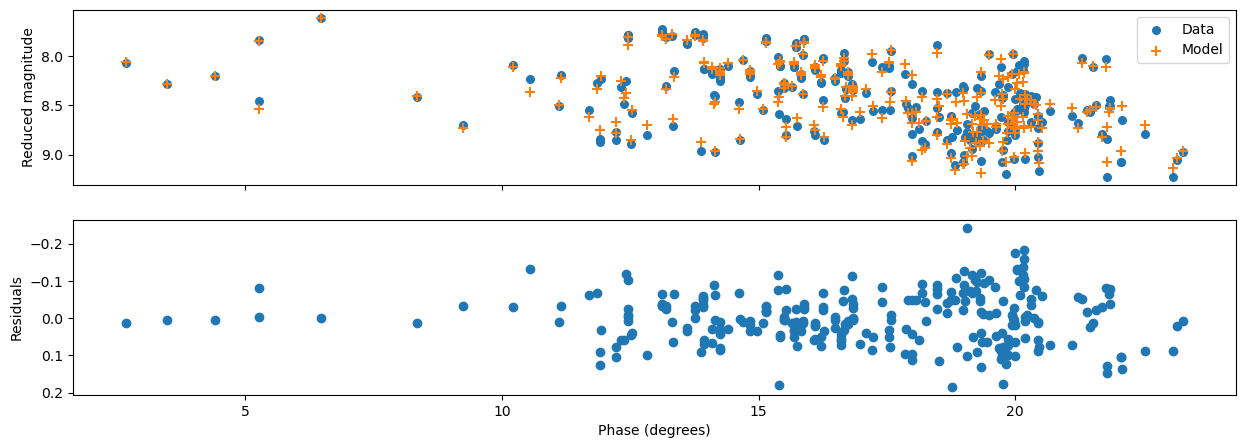

In [73]:
fig, ax = plt.subplots(2,1, figsize=(15,5), sharex=True)

x = data["Phase"]
obs = data["i:magpsf_red"]
model_SOCCA = pc.SOCCA.eval(pc)

ax[0].scatter(x, obs, label="Data", s=30)
ax[0].scatter(x, model_SOCCA, marker="+", label="Model", s=60)
ax[0].legend()
ax[0].set_ylabel("Reduced magnitude")

ax[1].scatter(x, obs-model_SOCCA)
ax[1].set_ylabel("Residuals")
ax[1].set_xlabel("Phase (degrees)")
for a in ax:
    a.invert_yaxis()